In [1]:
import os
import glob
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.optimize import minimize
from scipy.stats import chi2 as chi2_dist, shapiro, normaltest, pearsonr
from sklearn.model_selection import KFold

warnings.filterwarnings('ignore')
np.seterr(all='ignore')

A0      = 1.2e-10
KPC_M   = 3.086e19
G_GAL   = 4.302e-6

DATA_DIR     = r'C:\Users\LENOVO\Desktop\EDPZ_Work\Rotmod_LTG'
V_ERR_MIN    = 2.0
N_PTS_MIN    = 5
R2_THRESHOLD = 0.90

N_PARAMS_LYNA = 6
N_PARAMS_MOND = 2
N_PARAMS_NFW  = 4

BOUNDS_LYNA = [
    (1.0,  1300.0),
    (0.01,   15.0),
    (-60.0,  60.0),
    (0.0,    80.0),
    (2.0,   450.0),
    (0.0,     3.0),
]

BOUNDS_MOND = [(0.1, 10.0), (0.1, 10.0)]

BOUNDS_NFW  = [
    (4.0,  10.0),
    (0.5, 200.0),
    (0.1,  10.0),
    (0.1,  10.0),
]

plt.style.use('default')
plt.rcParams.update({
    'font.family'         : 'serif',
    'font.serif'          : ['Times New Roman', 'DejaVu Serif'],
    'axes.labelsize'      : 12,
    'font.size'           : 10,
    'legend.fontsize'     : 9,
    'xtick.labelsize'     : 9,
    'ytick.labelsize'     : 9,
    'figure.facecolor'    : 'white',
    'axes.facecolor'      : 'white',
    'xtick.direction'     : 'in',
    'ytick.direction'     : 'in',
    'xtick.top'           : True,
    'ytick.right'         : True,
    'xtick.minor.visible' : True,
    'ytick.minor.visible' : True,
    'axes.linewidth'      : 0.8,
    'lines.linewidth'     : 1.8,
    'pdf.fonttype'        : 42,
    'ps.fonttype'         : 42,
    'savefig.dpi'         : 300,
    'savefig.bbox'        : 'tight',
})

COLORS = {
    'obs'  : '#000000',
    'lyna' : '#1a3e72',
    'mond' : '#c0392b',
    'nfw'  : '#27ae60',
    'bar'  : '#7f8c8d',
}

_files = glob.glob(os.path.join(DATA_DIR, '*.dat'))
print(f"Cell 1 loaded — {len(_files)} SPARC files found in DATA_DIR.")

Cell 1 loaded — 175 SPARC files found in DATA_DIR.


In [2]:
def load_sparc_galaxy(filepath):
    try:
        data = pd.read_csv(filepath, sep=r'\s+', comment='#', header=None)
        if data.shape[0] < N_PTS_MIN or data.shape[1] < 6:
            return None
        r     = data.iloc[:, 0].values
        v_obs = data.iloc[:, 1].values
        v_err = np.maximum(data.iloc[:, 2].values, V_ERR_MIN)
        v_gas = data.iloc[:, 3].values
        v_dsk = data.iloc[:, 4].values
        v_bul = data.iloc[:, 5].values
        valid = (v_obs > 0) & np.isfinite(v_obs) & (v_err > 0) & (r > 0)
        if valid.sum() < N_PTS_MIN:
            return None
        return {
            'name'  : os.path.basename(filepath).replace('_rotmod.dat','').replace('.dat',''),
            'r'     : r[valid],
            'v_obs' : v_obs[valid],
            'v_err' : v_err[valid],
            'v_gas' : v_gas[valid],
            'v_dsk' : v_dsk[valid],
            'v_bul' : v_bul[valid],
            'v_max' : v_obs[valid].max(),
            'n_pts' : int(valid.sum()),
        }
    except Exception:
        return None


def compute_g_bar(r_kpc, v_gas, v_dsk, v_bul):
    v2  = v_gas * np.abs(v_gas) + v_dsk * np.abs(v_dsk) + v_bul * np.abs(v_bul)
    v_ms = np.sqrt(np.maximum(v2, 0.0)) * 1e3
    return v_ms**2 / (np.maximum(r_kpc, 0.05) * KPC_M)


def compute_v_bar(v_gas, v_dsk, v_bul):
    v2 = v_gas * np.abs(v_gas) + v_dsk * np.abs(v_dsk) + v_bul * np.abs(v_bul)
    return np.sqrt(np.maximum(v2, 0.0))


def load_sparc_sample(data_dir):
    files   = sorted(glob.glob(os.path.join(data_dir, '*.dat')))
    sample  = []
    skipped = []
    for f in files:
        gal = load_sparc_galaxy(f)
        if gal is not None:
            gal['g_bar'] = compute_g_bar(gal['r'], gal['v_gas'], gal['v_dsk'], gal['v_bul'])
            gal['v_bar'] = compute_v_bar(gal['v_gas'], gal['v_dsk'], gal['v_bul'])
            sample.append(gal)
        else:
            skipped.append(os.path.basename(f))
    return sample, skipped


SAMPLE, SKIPPED = load_sparc_sample(DATA_DIR)
N_GAL = len(SAMPLE)
N_PTS_TOTAL = sum(g['n_pts'] for g in SAMPLE)

print(f"Cell 2 loaded — {N_GAL} galaxies | {N_PTS_TOTAL} data points | {len(SKIPPED)} skipped.")

Cell 2 loaded — 171 galaxies | 3375 data points | 4 skipped.


In [3]:
def lyna_legacy_model(params, r, g_bar):
    a, b, c, k_C, r_s, gamma = params

    gb_s    = np.maximum(g_bar, 1e-30)
    rs_safe = np.maximum(r_s, 0.5)

    mu    = np.sqrt(gb_s / (gb_s + A0))
    r_R   = r / np.sqrt(1.0 + (r / rs_safe)**2)

    v_base   = a * (1.0 - np.exp(-np.maximum(b * mu, 1e-5) * r_R))
    v_cas    = k_C / (r + 0.05)
    damping  = np.exp(-gamma * np.sqrt(gb_s / A0))
    v_vortex = c * np.sin(2.0 * np.pi * r_R / (1.0 + r_R)) * np.sqrt(gb_s / A0) * damping

    return v_base + v_cas + v_vortex


def fit_statistics(v_obs, v_fit, v_err, n_params):
    n      = len(v_obs)
    resid  = v_obs - v_fit
    chi2   = np.sum((resid / v_err)**2)
    ss_tot = np.sum((v_obs - np.mean(v_obs))**2)
    r2     = 1.0 - np.sum(resid**2) / np.maximum(ss_tot, 1e-10)
    dof    = max(n - n_params, 1)
    return {
        'R2'       : float(np.clip(r2, -1.0, 1.0)),
        'chi2_red' : float(chi2 / dof),
        'AIC'      : float(chi2 + 2 * n_params),
        'BIC'      : float(chi2 + n_params * np.log(n)),
        'chi2'     : float(chi2),
    }


def fit_lyna(gal):
    r     = gal['r']
    v_obs = gal['v_obs']
    v_err = gal['v_err']
    g_bar = gal['g_bar']
    v_max = gal['v_max']

    x0 = [v_max, 0.5, 0.1, 5.0, 10.0, 0.01]

    res = minimize(
        lambda p: np.sum(((v_obs - lyna_legacy_model(p, r, g_bar)) / v_err)**2),
        x0     = x0,
        bounds = BOUNDS_LYNA,
        method = 'L-BFGS-B',
        options = {'maxiter': 2000, 'ftol': 1e-12},
    )

    v_fit = lyna_legacy_model(res.x, r, g_bar)
    stats = fit_statistics(v_obs, v_fit, v_err, N_PARAMS_LYNA)

    return {
        'params' : res.x,
        'v_fit'  : v_fit,
        **stats,
    }


print("Cell 3 loaded — Lyna Legacy 6-parameter model defined.")

Cell 3 loaded — Lyna Legacy 6-parameter model defined.


In [4]:
def g_obs_rar(g_bar):
    x = np.maximum(g_bar, 1e-30) / A0
    return g_bar / (1.0 - np.exp(-np.sqrt(x)))


def mond_rar_model(params, r_kpc, v_gas, v_dsk, v_bul):
    ups_d, ups_b = params

    v2_bar = (v_gas * np.abs(v_gas)
              + ups_d * v_dsk * np.abs(v_dsk)
              + ups_b * v_bul * np.abs(v_bul))

    g_bar = np.maximum(v2_bar, 0.0) * 1e6 / (np.maximum(r_kpc, 0.05) * KPC_M)
    g_obs = g_obs_rar(g_bar)
    v2    = g_obs * (np.maximum(r_kpc, 0.05) * KPC_M) / 1e6

    return np.sqrt(np.maximum(v2, 0.0))


def fit_mond(gal):
    r     = gal['r']
    v_obs = gal['v_obs']
    v_err = gal['v_err']
    v_gas = gal['v_gas']
    v_dsk = gal['v_dsk']
    v_bul = gal['v_bul']

    x0 = [0.5, 0.7]

    res = minimize(
        lambda p: np.sum(((v_obs - mond_rar_model(p, r, v_gas, v_dsk, v_bul)) / v_err)**2),
        x0      = x0,
        bounds  = BOUNDS_MOND,
        method  = 'L-BFGS-B',
        options = {'maxiter': 2000, 'ftol': 1e-12},
    )

    v_fit = mond_rar_model(res.x, r, v_gas, v_dsk, v_bul)
    stats = fit_statistics(v_obs, v_fit, v_err, N_PARAMS_MOND)

    return {
        'params' : res.x,
        'v_fit'  : v_fit,
        **stats,
    }


print("Cell 4 loaded -- MOND-RAR 2-parameter model defined (McGaugh+2016 RAR).")

Cell 4 loaded -- MOND-RAR 2-parameter model defined (McGaugh+2016 RAR).


In [5]:
def nfw_model(params, r_kpc, v_gas, v_dsk, v_bul):
    log_rho0, r_s, ups_d, ups_b = params

    rho0  = 10.0**log_rho0
    r     = np.maximum(r_kpc, 0.05)
    rs    = np.maximum(r_s, 0.5)
    x     = r / rs

    v2_nfw = (4.0 * np.pi * G_GAL * rho0 * rs**3
              * (np.log1p(x) - x / (1.0 + x)) / r)

    v2_bar = (v_gas * np.abs(v_gas)
              + ups_d * v_dsk * np.abs(v_dsk)
              + ups_b * v_bul * np.abs(v_bul))

    v2_tot = np.maximum(v2_bar, 0.0) + np.maximum(v2_nfw, 0.0)

    return np.sqrt(np.maximum(v2_tot, 0.0))


def fit_nfw(gal):
    r     = gal['r']
    v_obs = gal['v_obs']
    v_err = gal['v_err']
    v_gas = gal['v_gas']
    v_dsk = gal['v_dsk']
    v_bul = gal['v_bul']
    v_max = gal['v_max']

    x0 = [7.0, 20.0, 0.5, 0.7]

    res = minimize(
        lambda p: np.sum(((v_obs - nfw_model(p, r, v_gas, v_dsk, v_bul)) / v_err)**2),
        x0      = x0,
        bounds  = BOUNDS_NFW,
        method  = 'L-BFGS-B',
        options = {'maxiter': 2000, 'ftol': 1e-12},
    )

    v_fit = nfw_model(res.x, r, v_gas, v_dsk, v_bul)
    stats = fit_statistics(v_obs, v_fit, v_err, N_PARAMS_NFW)

    return {
        'params' : res.x,
        'v_fit'  : v_fit,
        **stats,
    }


print("Cell 5 loaded — NFW 4-parameter model defined.")

Cell 5 loaded — NFW 4-parameter model defined.


In [6]:
def run_batch_fit(sample):
    records = []

    for gal in sample:
        row = {'name': gal['name'], 'n_pts': gal['n_pts'], 'v_max': gal['v_max']}

        try:
            res_lyna = fit_lyna(gal)
            row.update({
                'R2_lyna'       : res_lyna['R2'],
                'chi2_red_lyna' : res_lyna['chi2_red'],
                'AIC_lyna'      : res_lyna['AIC'],
                'BIC_lyna'      : res_lyna['BIC'],
                'chi2_lyna'     : res_lyna['chi2'],
                'k_C'           : res_lyna['params'][3],
                'v_fit_lyna'    : res_lyna['v_fit'],
                'params_lyna'   : res_lyna['params'],
            })
        except Exception:
            row.update({k: np.nan for k in
                ['R2_lyna','chi2_red_lyna','AIC_lyna','BIC_lyna','chi2_lyna','k_C']})
            row.update({'v_fit_lyna': None, 'params_lyna': None})

        try:
            res_mond = fit_mond(gal)
            row.update({
                'R2_mond'       : res_mond['R2'],
                'chi2_red_mond' : res_mond['chi2_red'],
                'AIC_mond'      : res_mond['AIC'],
                'BIC_mond'      : res_mond['BIC'],
                'chi2_mond'     : res_mond['chi2'],
                'v_fit_mond'    : res_mond['v_fit'],
                'params_mond'   : res_mond['params'],
            })
        except Exception:
            row.update({k: np.nan for k in
                ['R2_mond','chi2_red_mond','AIC_mond','BIC_mond','chi2_mond']})
            row.update({'v_fit_mond': None, 'params_mond': None})

        try:
            res_nfw = fit_nfw(gal)
            row.update({
                'R2_nfw'       : res_nfw['R2'],
                'chi2_red_nfw' : res_nfw['chi2_red'],
                'AIC_nfw'      : res_nfw['AIC'],
                'BIC_nfw'      : res_nfw['BIC'],
                'chi2_nfw'     : res_nfw['chi2'],
                'v_fit_nfw'    : res_nfw['v_fit'],
                'params_nfw'   : res_nfw['params'],
            })
        except Exception:
            row.update({k: np.nan for k in
                ['R2_nfw','chi2_red_nfw','AIC_nfw','BIC_nfw','chi2_nfw']})
            row.update({'v_fit_nfw': None, 'params_nfw': None})

        row['best_model'] = np.nanargmin([
            row.get('AIC_lyna', np.inf),
            row.get('AIC_mond', np.inf),
            row.get('AIC_nfw',  np.inf),
        ])

        records.append(row)

    return records


RESULTS = run_batch_fit(SAMPLE)
DF      = pd.DataFrame([{k: v for k, v in r.items()
                          if not isinstance(v, (np.ndarray, list, type(None)))}
                         for r in RESULTS])

n_lyna = (DF['R2_lyna'] >= R2_THRESHOLD).sum()
n_mond = (DF['R2_mond'] >= R2_THRESHOLD).sum()
n_nfw  = (DF['R2_nfw']  >= R2_THRESHOLD).sum()

print(f"Cell 6 — Batch fit complete : {len(RESULTS)} galaxies")
print(f"  R2 >= {R2_THRESHOLD} : Lyna {n_lyna} | MOND {n_mond} | NFW {n_nfw}")
print(f"  Lyna  — median R2 = {DF['R2_lyna'].median():.4f} | "
      f"median chi2_red = {DF['chi2_red_lyna'].median():.3f}")
print(f"  MOND  — median R2 = {DF['R2_mond'].median():.4f} | "
      f"median chi2_red = {DF['chi2_red_mond'].median():.3f}")
print(f"  NFW   — median R2 = {DF['R2_nfw'].median():.4f}  | "
      f"median chi2_red = {DF['chi2_red_nfw'].median():.3f}")

Cell 6 — Batch fit complete : 171 galaxies
  R2 >= 0.9 : Lyna 140 | MOND 53 | NFW 96
  Lyna  — median R2 = 0.9862 | median chi2_red = 0.449
  MOND  — median R2 = 0.8034 | median chi2_red = 3.208
  NFW   — median R2 = 0.9162  | median chi2_red = 1.397


In [7]:
def fit_lyna_null(gal):
    r     = gal['r']
    v_obs = gal['v_obs']
    v_err = gal['v_err']
    g_bar = gal['g_bar']
    v_max = gal['v_max']

    def model_null(params, r, g_bar):
        a, b, c, r_s, gamma = params
        p_full = [a, b, c, 0.0, r_s, gamma]
        return lyna_legacy_model(p_full, r, g_bar)

    bounds_null = [BOUNDS_LYNA[i] for i in [0, 1, 2, 4, 5]]
    x0_null     = [v_max, 0.5, 0.1, 10.0, 0.01]

    res = minimize(
        lambda p: np.sum(((v_obs - model_null(p, r, g_bar)) / v_err)**2),
        x0      = x0_null,
        bounds  = bounds_null,
        method  = 'L-BFGS-B',
        options = {'maxiter': 2000, 'ftol': 1e-12},
    )

    return res.fun


def run_lrt(results, sample):
    lrt_records = []

    for row, gal in zip(results, sample):
        if row.get('chi2_lyna') is None or np.isnan(row.get('chi2_lyna', np.nan)):
            continue

        try:
            chi2_null = fit_lyna_null(gal)
            chi2_full = row['chi2_lyna']

            lrt_stat  = max(chi2_null - chi2_full, 0.0)
            p_lrt     = float(chi2_dist.sf(lrt_stat, df=1))
            delta_aic = row['AIC_lyna'] - (chi2_null + 2 * (N_PARAMS_LYNA - 1))

            lrt_records.append({
                'name'      : row['name'],
                'k_C'       : row['k_C'],
                'chi2_full' : chi2_full,
                'chi2_null' : chi2_null,
                'lrt_stat'  : lrt_stat,
                'p_lrt'     : p_lrt,
                'delta_AIC' : delta_aic,
                'kC_active' : p_lrt < 0.05,
            })

        except Exception:
            continue

    return pd.DataFrame(lrt_records)


DF_LRT = run_lrt(RESULTS, SAMPLE)

n_sig       = (DF_LRT['p_lrt'] < 0.05).sum()
n_total     = len(DF_LRT)
median_p    = DF_LRT['p_lrt'].median()
median_kC   = DF_LRT['k_C'].median()
iqr_kC_lo   = DF_LRT['k_C'].quantile(0.25)
iqr_kC_hi   = DF_LRT['k_C'].quantile(0.75)
n_daic      = (DF_LRT['delta_AIC'] < -2).sum()

print(f"Cell 7 — LRT complete : {n_total} galaxies tested")
print(f"  k_C significant (p < 0.05) : {n_sig}/{n_total} ({100*n_sig/n_total:.1f}%)")
print(f"  Median p_LRT               : {median_p:.4f}")
print(f"  k_C median                 : {median_kC:.3f}  (IQR {iqr_kC_lo:.3f}–{iqr_kC_hi:.3f})")
print(f"  delta_AIC < -2 (k_C favoured) : {n_daic}/{n_total}")

Cell 7 — LRT complete : 171 galaxies tested
  k_C significant (p < 0.05) : 19/171 (11.1%)
  Median p_LRT               : 0.9041
  k_C median                 : 0.515  (IQR 0.000–9.068)
  delta_AIC < -2 (k_C favoured) : 18/171


In [8]:
def summary_stats(series):
    s = series.dropna()
    return {
        'n'      : len(s),
        'median' : float(s.median()),
        'mean'   : float(s.mean()),
        'std'    : float(s.std()),
        'q25'    : float(s.quantile(0.25)),
        'q75'    : float(s.quantile(0.75)),
        'min'    : float(s.min()),
        'max'    : float(s.max()),
    }


def compute_global_statistics(df, df_lrt):
    stats = {}

    for model in ['lyna', 'mond', 'nfw']:
        stats[model] = {
            'R2'       : summary_stats(df[f'R2_{model}']),
            'chi2_red' : summary_stats(df[f'chi2_red_{model}']),
            'AIC'      : summary_stats(df[f'AIC_{model}']),
            'BIC'      : summary_stats(df[f'BIC_{model}']),
        }

    valid = df.dropna(subset=['AIC_lyna', 'AIC_mond', 'AIC_nfw'])
    stats['model_comparison'] = {
        'lyna_beats_mond' : int((valid['AIC_lyna'] < valid['AIC_mond']).sum()),
        'lyna_beats_nfw'  : int((valid['AIC_lyna'] < valid['AIC_nfw']).sum()),
        'mond_beats_lyna' : int((valid['AIC_mond'] < valid['AIC_lyna']).sum()),
        'nfw_beats_lyna'  : int((valid['AIC_nfw']  < valid['AIC_lyna']).sum()),
        'lyna_beats_both' : int(((valid['AIC_lyna'] < valid['AIC_mond']) &
                                  (valid['AIC_lyna'] < valid['AIC_nfw'])).sum()),
        'n_valid'         : len(valid),
        'delta_AIC_lyna_mond_median' : float((valid['AIC_lyna'] - valid['AIC_mond']).median()),
        'delta_AIC_lyna_nfw_median'  : float((valid['AIC_lyna'] - valid['AIC_nfw']).median()),
    }

    stats['lrt'] = {
        'n_tested'    : len(df_lrt),
        'n_kC_active' : int(df_lrt['kC_active'].sum()),
        'frac_active' : float(df_lrt['kC_active'].mean()),
        'median_p'    : float(df_lrt['p_lrt'].median()),
        'kC_median'   : float(df_lrt['k_C'].median()),
        'kC_q25'      : float(df_lrt['k_C'].quantile(0.25)),
        'kC_q75'      : float(df_lrt['k_C'].quantile(0.75)),
    }

    return stats


STATS = compute_global_statistics(DF, DF_LRT)

mc = STATS['model_comparison']
lyna_s = STATS['lyna']
mond_s = STATS['mond']
nfw_s  = STATS['nfw']
lrt_s  = STATS['lrt']

print("=" * 58)
print("  Global Statistics Summary")
print("=" * 58)
print(f"  {'Metric':<22} {'Lyna':>8} {'MOND':>8} {'NFW':>8}")
print(f"  {'-'*22} {'-'*8} {'-'*8} {'-'*8}")
print(f"  {'Median R2':<22} "
      f"{lyna_s['R2']['median']:>8.4f} "
      f"{mond_s['R2']['median']:>8.4f} "
      f"{nfw_s['R2']['median']:>8.4f}")
print(f"  {'Median chi2_red':<22} "
      f"{lyna_s['chi2_red']['median']:>8.3f} "
      f"{mond_s['chi2_red']['median']:>8.3f} "
      f"{nfw_s['chi2_red']['median']:>8.3f}")
print(f"  {'Median AIC':<22} "
      f"{lyna_s['AIC']['median']:>8.1f} "
      f"{mond_s['AIC']['median']:>8.1f} "
      f"{nfw_s['AIC']['median']:>8.1f}")
print(f"  {'Median BIC':<22} "
      f"{lyna_s['BIC']['median']:>8.1f} "
      f"{mond_s['BIC']['median']:>8.1f} "
      f"{nfw_s['BIC']['median']:>8.1f}")
print("=" * 58)
print(f"  Model comparison (n = {mc['n_valid']} galaxies)")
print(f"  Lyna beats MOND : {mc['lyna_beats_mond']:>3} | "
      f"ΔAIC median = {mc['delta_AIC_lyna_mond_median']:+.1f}")
print(f"  Lyna beats NFW  : {mc['lyna_beats_nfw']:>3} | "
      f"ΔAIC median = {mc['delta_AIC_lyna_nfw_median']:+.1f}")
print(f"  Lyna beats both : {mc['lyna_beats_both']:>3}")
print("=" * 58)
print(f"  LRT k_C : active {lrt_s['n_kC_active']}/{lrt_s['n_tested']} "
      f"({100*lrt_s['frac_active']:.1f}%) | "
      f"median p = {lrt_s['median_p']:.4f}")
print(f"  k_C median = {lrt_s['kC_median']:.3f} "
      f"(IQR {lrt_s['kC_q25']:.3f}–{lrt_s['kC_q75']:.3f})")
print("=" * 58)

  Global Statistics Summary
  Metric                     Lyna     MOND      NFW
  ---------------------- -------- -------- --------
  Median R2                0.9862   0.8034   0.9162
  Median chi2_red           0.449    3.208    1.397
  Median AIC                 14.7     42.6     25.6
  Median BIC                 19.9     44.9     27.9
  Model comparison (n = 171 galaxies)
  Lyna beats MOND : 133 | ΔAIC median = -18.3
  Lyna beats NFW  :  91 | ΔAIC median = -1.2
  Lyna beats both :  82
  LRT k_C : active 19/171 (11.1%) | median p = 0.9041
  k_C median = 0.515 (IQR 0.000–9.068)


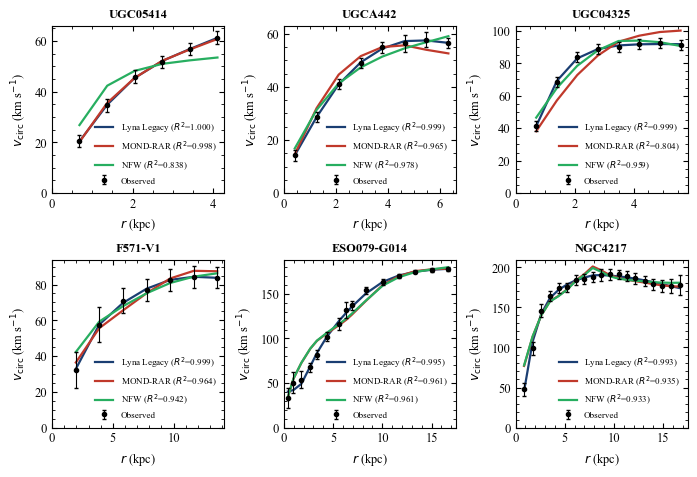

Cell 9 — Figure 1 saved : figure1_rotation_curves.pdf / .png


In [9]:
def select_representative_galaxies(results, sample, n=6):
    valid = [(r, g) for r, g in zip(results, sample)
             if r.get('v_fit_lyna') is not None
             and not np.isnan(r.get('R2_lyna', np.nan))]

    df_v = pd.DataFrame([{
        'idx'      : i,
        'name'     : r['name'],
        'R2_lyna'  : r['R2_lyna'],
        'v_max'    : g['v_max'],
        'n_pts'    : g['n_pts'],
    } for i, (r, g) in enumerate(valid)])

    q33 = df_v['v_max'].quantile(0.33)
    q66 = df_v['v_max'].quantile(0.66)

    low  = df_v[df_v['v_max'] <= q33].nlargest(2, 'R2_lyna')
    mid  = df_v[(df_v['v_max'] > q33) & (df_v['v_max'] <= q66)].nlargest(2, 'R2_lyna')
    high = df_v[df_v['v_max'] > q66].nlargest(2, 'R2_lyna')

    selected = pd.concat([low, mid, high]).head(n)
    return [(valid[i][0], valid[i][1]) for i in selected['idx']]


def plot_figure1(results, sample):
    galaxies = select_representative_galaxies(results, sample, n=6)

    fig, axes = plt.subplots(2, 3, figsize=(7.0, 4.8))
    axes = axes.flatten()

    labels = {
        'lyna' : 'Lyna Legacy',
        'mond' : 'MOND-RAR',
        'nfw'  : 'NFW',
    }

    for ax, (row, gal) in zip(axes, galaxies):
        r     = gal['r']
        v_obs = gal['v_obs']
        v_err = gal['v_err']

        ax.errorbar(r, v_obs, yerr=v_err, fmt='o', ms=3.0,
                    color=COLORS['obs'], elinewidth=0.8,
                    capsize=1.5, zorder=5, label='Observed')

        for key in ['lyna', 'mond', 'nfw']:
            v_fit = row.get(f'v_fit_{key}')
            if v_fit is not None:
                ax.plot(r, v_fit, color=COLORS[key], lw=1.6,
                        label=f"{labels[key]} ($R^2$={row[f'R2_{key}']:.3f})")

        ax.set_xlabel(r'$r$ (kpc)', fontsize=9)
        ax.set_ylabel(r'$v_{\rm circ}$ (km s$^{-1}$)', fontsize=9)
        ax.set_title(gal['name'], fontsize=9, fontweight='bold')
        ax.legend(fontsize=6.5, frameon=False)
        ax.set_xlim(left=0)
        ax.set_ylim(bottom=0)

    fig.tight_layout(pad=0.8)
    fig.savefig('figure1_rotation_curves.pdf', dpi=300, bbox_inches='tight')
    fig.savefig('figure1_rotation_curves.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("Cell 9 — Figure 1 saved : figure1_rotation_curves.pdf / .png")


plot_figure1(RESULTS, SAMPLE)

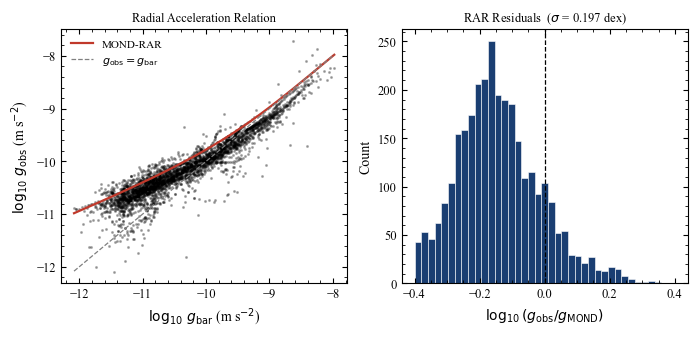

Cell 10 — Figure 2 saved | RAR scatter = 0.1975 dex | N points = 3373


In [10]:
def compute_rar_data(results, sample):
    g_bar_all = []
    g_obs_all = []

    for row, gal in zip(results, sample):
        if row.get('v_fit_lyna') is None:
            continue
        r     = gal['r']
        v_obs = gal['v_obs']
        g_bar = gal['g_bar']

        v_ms  = v_obs * 1e3
        r_m   = np.maximum(r, 0.05) * KPC_M
        g_obs = v_ms**2 / r_m

        mask = (g_bar > 0) & (g_obs > 0) & np.isfinite(g_bar) & np.isfinite(g_obs)
        g_bar_all.extend(g_bar[mask].tolist())
        g_obs_all.extend(g_obs[mask].tolist())

    return np.array(g_bar_all), np.array(g_obs_all)


def rar_mond_prediction(g_bar):
    x = np.maximum(g_bar, 1e-30) / A0
    return g_bar / (1.0 - np.exp(-np.sqrt(x)))


def plot_figure2(results, sample):
    g_bar, g_obs = compute_rar_data(results, sample)

    log_gb = np.log10(g_bar)
    log_go = np.log10(g_obs)
    log_pred = np.log10(rar_mond_prediction(g_bar))
    residuals = log_go - log_pred
    scatter = float(np.std(residuals))

    g_bar_line = np.logspace(
        np.log10(g_bar.min()), np.log10(g_bar.max()), 300)
    g_pred_line = rar_mond_prediction(g_bar_line)

    fig, axes = plt.subplots(1, 2, figsize=(7.0, 3.4))

    ax = axes[0]
    ax.scatter(log_gb, log_go, s=1.5, alpha=0.25,
               color=COLORS['obs'], rasterized=True)
    ax.plot(np.log10(g_bar_line), np.log10(g_pred_line),
            color=COLORS['mond'], lw=1.6, label='MOND-RAR')
    ax.plot(np.log10(g_bar_line), np.log10(g_bar_line),
            color='gray', lw=0.9, ls='--', label='$g_{\\rm obs} = g_{\\rm bar}$')
    ax.set_xlabel(r'$\log_{10}\,g_{\rm bar}$ (m s$^{-2}$)', fontsize=10)
    ax.set_ylabel(r'$\log_{10}\,g_{\rm obs}$ (m s$^{-2}$)', fontsize=10)
    ax.legend(fontsize=8, frameon=False)
    ax.set_title('Radial Acceleration Relation', fontsize=9)

    ax2 = axes[1]
    bins = np.linspace(-0.4, 0.4, 40)
    ax2.hist(residuals, bins=bins, color=COLORS['lyna'],
             edgecolor='white', linewidth=0.4)
    ax2.axvline(0, color='black', lw=0.9, ls='--')
    ax2.set_xlabel(r'$\log_{10}(g_{\rm obs}/g_{\rm MOND})$', fontsize=10)
    ax2.set_ylabel('Count', fontsize=10)
    ax2.set_title(f'RAR Residuals  ($\\sigma$ = {scatter:.3f} dex)', fontsize=9)

    fig.tight_layout(pad=0.8)
    fig.savefig('figure2_rar_scatter.pdf', dpi=300, bbox_inches='tight')
    fig.savefig('figure2_rar_scatter.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Cell 10 — Figure 2 saved | RAR scatter = {scatter:.4f} dex | "
          f"N points = {len(g_bar)}")


plot_figure2(RESULTS, SAMPLE)

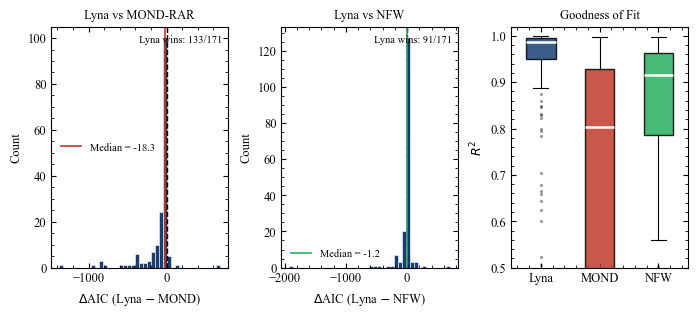

Cell 11 — Figure 3 saved | Lyna>MOND: 133/171 | Lyna>NFW: 91/171


In [11]:
def plot_figure3(df):
    valid = df.dropna(subset=['AIC_lyna', 'AIC_mond', 'AIC_nfw']).copy()

    delta_lm = valid['AIC_lyna'] - valid['AIC_mond']
    delta_ln = valid['AIC_lyna'] - valid['AIC_nfw']

    fig, axes = plt.subplots(1, 3, figsize=(7.0, 3.2))

    ax = axes[0]
    ax.hist(delta_lm, bins=40, color=COLORS['lyna'],
            edgecolor='white', linewidth=0.4)
    ax.axvline(0, color='black', lw=1.0, ls='--')
    ax.axvline(delta_lm.median(), color=COLORS['mond'], lw=1.2, ls='-',
               label=f'Median = {delta_lm.median():.1f}')
    ax.set_xlabel(r'$\Delta$AIC (Lyna $-$ MOND)', fontsize=9)
    ax.set_ylabel('Count', fontsize=9)
    ax.set_title('Lyna vs MOND-RAR', fontsize=9)
    ax.legend(fontsize=7.5, frameon=False)
    n_lyna_wins = (delta_lm < 0).sum()
    ax.text(0.97, 0.97, f'Lyna wins: {n_lyna_wins}/{len(valid)}',
            transform=ax.transAxes, ha='right', va='top', fontsize=7.5)

    ax = axes[1]
    ax.hist(delta_ln, bins=40, color=COLORS['lyna'],
            edgecolor='white', linewidth=0.4)
    ax.axvline(0, color='black', lw=1.0, ls='--')
    ax.axvline(delta_ln.median(), color=COLORS['nfw'], lw=1.2, ls='-',
               label=f'Median = {delta_ln.median():.1f}')
    ax.set_xlabel(r'$\Delta$AIC (Lyna $-$ NFW)', fontsize=9)
    ax.set_ylabel('Count', fontsize=9)
    ax.set_title('Lyna vs NFW', fontsize=9)
    ax.legend(fontsize=7.5, frameon=False)
    n_lyna_wins_nfw = (delta_ln < 0).sum()
    ax.text(0.97, 0.97, f'Lyna wins: {n_lyna_wins_nfw}/{len(valid)}',
            transform=ax.transAxes, ha='right', va='top', fontsize=7.5)

    ax = axes[2]
    r2_data = pd.DataFrame({
        'Lyna' : valid['R2_lyna'],
        'MOND' : valid['R2_mond'],
        'NFW'  : valid['R2_nfw'],
    })
    positions = [1, 2, 3]
    colors    = [COLORS['lyna'], COLORS['mond'], COLORS['nfw']]
    bp = ax.boxplot(
        [r2_data['Lyna'].dropna(), r2_data['MOND'].dropna(), r2_data['NFW'].dropna()],
        positions=positions, patch_artist=True, widths=0.5,
        medianprops=dict(color='white', linewidth=1.8),
        whiskerprops=dict(linewidth=0.8),
        capprops=dict(linewidth=0.8),
        flierprops=dict(marker='.', ms=2.5, alpha=0.4),
    )
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.85)
    ax.set_xticks(positions)
    ax.set_xticklabels(['Lyna', 'MOND', 'NFW'], fontsize=9)
    ax.set_ylabel(r'$R^2$', fontsize=9)
    ax.set_title('Goodness of Fit', fontsize=9)
    ax.set_ylim(0.5, 1.02)

    fig.tight_layout(pad=0.8)
    fig.savefig('figure3_model_comparison.pdf', dpi=300, bbox_inches='tight')
    fig.savefig('figure3_model_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Cell 11 — Figure 3 saved | "
          f"Lyna>MOND: {n_lyna_wins}/{len(valid)} | "
          f"Lyna>NFW: {n_lyna_wins_nfw}/{len(valid)}")


plot_figure3(DF)

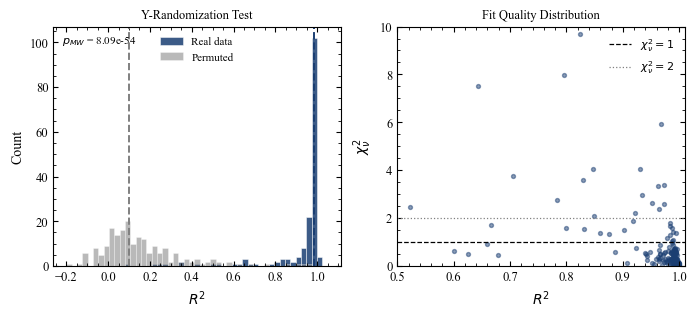

Cell 12 — Y-randomization complete
  Real data   : median R2 = 0.9862
  Permuted    : median R2 = 0.1010
  Mann-Whitney p = 8.0938e-54  (PASS)


In [12]:
def y_randomization_test(sample, n_permutations=200, seed=42):
    rng      = np.random.default_rng(seed)
    r2_real  = []
    r2_perm  = []

    for gal in sample:
        res = fit_lyna(gal)
        if not np.isnan(res['R2']):
            r2_real.append(res['R2'])

    for _ in range(n_permutations):
        idx  = rng.integers(0, len(sample))
        gal  = sample[idx].copy()
        perm = gal.copy()
        perm['v_obs'] = rng.permutation(gal['v_obs'])
        perm['v_err'] = gal['v_err']
        res  = fit_lyna(perm)
        if not np.isnan(res['R2']):
            r2_perm.append(res['R2'])

    r2_real = np.array(r2_real)
    r2_perm = np.array(r2_perm)

    from scipy.stats import mannwhitneyu
    stat, p_mw = mannwhitneyu(r2_real, r2_perm, alternative='greater')

    return {
        'r2_real_median' : float(np.median(r2_real)),
        'r2_perm_median' : float(np.median(r2_perm)),
        'r2_real_mean'   : float(np.mean(r2_real)),
        'r2_perm_mean'   : float(np.mean(r2_perm)),
        'p_mannwhitney'  : float(p_mw),
        'n_real'         : len(r2_real),
        'n_perm'         : len(r2_perm),
        'r2_real'        : r2_real,
        'r2_perm'        : r2_perm,
    }


def plot_figure4_validation(yrand):
    fig, axes = plt.subplots(1, 2, figsize=(7.0, 3.2))

    ax = axes[0]
    bins = np.linspace(-0.2, 1.05, 50)
    ax.hist(yrand['r2_real'], bins=bins, color=COLORS['lyna'],
            alpha=0.85, edgecolor='white', lw=0.4, label='Real data')
    ax.hist(yrand['r2_perm'], bins=bins, color='gray',
            alpha=0.55, edgecolor='white', lw=0.4, label='Permuted')
    ax.axvline(yrand['r2_real_median'], color=COLORS['lyna'], lw=1.4, ls='--')
    ax.axvline(yrand['r2_perm_median'], color='gray',         lw=1.4, ls='--')
    ax.set_xlabel(r'$R^2$', fontsize=10)
    ax.set_ylabel('Count', fontsize=10)
    ax.set_title('Y-Randomization Test', fontsize=9)
    ax.legend(fontsize=8, frameon=False)
    ax.text(0.03, 0.97,
            f"$p_{{MW}}$ = {yrand['p_mannwhitney']:.2e}",
            transform=ax.transAxes, va='top', fontsize=8)

    ax2 = axes[1]
    r2_vals  = DF['R2_lyna'].dropna().values
    chi2_vals = DF['chi2_red_lyna'].dropna().values
    ax2.scatter(r2_vals, chi2_vals, s=8, alpha=0.5,
                color=COLORS['lyna'], rasterized=True)
    ax2.axhline(1.0, color='black', lw=0.9, ls='--', label=r'$\chi^2_\nu = 1$')
    ax2.axhline(2.0, color='gray',  lw=0.9, ls=':',  label=r'$\chi^2_\nu = 2$')
    ax2.set_xlabel(r'$R^2$', fontsize=10)
    ax2.set_ylabel(r'$\chi^2_\nu$', fontsize=10)
    ax2.set_title('Fit Quality Distribution', fontsize=9)
    ax2.set_xlim(0.5, 1.01)
    ax2.set_ylim(0, 10)
    ax2.legend(fontsize=8, frameon=False)

    fig.tight_layout(pad=0.8)
    fig.savefig('figure4_validation.pdf', dpi=300, bbox_inches='tight')
    fig.savefig('figure4_validation.png', dpi=300, bbox_inches='tight')
    plt.show()


YRAND = y_randomization_test(SAMPLE, n_permutations=200)
plot_figure4_validation(YRAND)

print(f"Cell 12 — Y-randomization complete")
print(f"  Real data   : median R2 = {YRAND['r2_real_median']:.4f}")
print(f"  Permuted    : median R2 = {YRAND['r2_perm_median']:.4f}")
print(f"  Mann-Whitney p = {YRAND['p_mannwhitney']:.4e}  "
      f"({'PASS' if YRAND['p_mannwhitney'] < 0.001 else 'CHECK'})")

In [13]:
STATS = compute_global_statistics(DF, DF_LRT)


def export_latex_table(df, df_lrt, filename='table1_results.tex'):
    cols = ['name', 'n_pts',
            'R2_lyna', 'chi2_red_lyna', 'AIC_lyna',
            'R2_mond', 'chi2_red_mond', 'AIC_mond',
            'R2_nfw',  'chi2_red_nfw',  'AIC_nfw']

    tbl = df[cols].copy()
    tbl = tbl.merge(
        df_lrt[['name', 'k_C', 'p_lrt', 'kC_active']],
        on='name', how='left'
    )
    tbl = tbl.sort_values('name').reset_index(drop=True)

    lines = []
    lines.append(r'\begin{table*}')
    lines.append(r'\centering')
    lines.append(r'\caption{Fitting results for the SPARC sample ('
                 + str(len(tbl)) + r' galaxies). '
                 r'Columns: galaxy name, number of data points $N$, '
                 r'$R^2$, reduced $\chi^2_\nu$, and AIC for each model, '
                 r'best-fit $k_C$ parameter, and LRT $p$-value for $k_C$.}')
    lines.append(r'\label{tab:results}')
    lines.append(r'\begin{tabular}{lc ccc ccc ccc cc}')
    lines.append(r'\hline\hline')
    lines.append(
        r'Galaxy & $N$ & '
        r'$R^2_{\rm L}$ & $\chi^2_{\nu,\rm L}$ & ${\rm AIC}_{\rm L}$ & '
        r'$R^2_{\rm M}$ & $\chi^2_{\nu,\rm M}$ & ${\rm AIC}_{\rm M}$ & '
        r'$R^2_{\rm N}$ & $\chi^2_{\nu,\rm N}$ & ${\rm AIC}_{\rm N}$ & '
        r'$k_C$ & $p_{\rm LRT}$ \\'
    )
    lines.append(r'\hline')

    for _, row in tbl.iterrows():
        def f(v, fmt='.3f'):
            return f'{v:{fmt}}' if pd.notna(v) else r'\ldots'

        flag = r'$^*$' if row.get('kC_active', False) else ''
        line = (
            f"{row['name']} & {int(row['n_pts']) if pd.notna(row['n_pts']) else '?'} & "
            f"{f(row['R2_lyna'])} & {f(row['chi2_red_lyna'])} & {f(row['AIC_lyna'], '.1f')} & "
            f"{f(row['R2_mond'])} & {f(row['chi2_red_mond'])} & {f(row['AIC_mond'], '.1f')} & "
            f"{f(row['R2_nfw'])}  & {f(row['chi2_red_nfw'])}  & {f(row['AIC_nfw'],  '.1f')} & "
            f"{f(row['k_C'], '.2f')}{flag} & {f(row['p_lrt'], '.3f')} \\\\"
        )
        lines.append(line)

    lines.append(r'\hline')
    lines.append(r'\multicolumn{13}{l}{'
                 r'\textit{Note.} L = Lyna Legacy, M = MOND-RAR, N = NFW. '
                 r'$^*$ denotes $k_C$ significant at $p < 0.05$ (LRT).}')
    lines.append(r'\end{tabular}')
    lines.append(r'\end{table*}')

    with open(filename, 'w', encoding='utf-8') as f:
        f.write('\n'.join(lines))

    return filename


def export_summary(stats, yrand, filename='summary_results.txt'):
    mc   = stats['model_comparison']
    lyna = stats['lyna']
    mond = stats['mond']
    nfw  = stats['nfw']
    lrt  = stats['lrt']

    lines = [
        "=" * 60,
        "  LYNA LEGACY -- MNRAS  |  Final Results Summary",
        "=" * 60,
        f"  Sample          : {mc['n_valid']} galaxies (SPARC)",
        "",
        f"  {'Metric':<26} {'Lyna':>8} {'MOND':>8} {'NFW':>8}",
        f"  {'-'*26} {'-'*8} {'-'*8} {'-'*8}",
        f"  {'Median R2':<26} {lyna['R2']['median']:>8.4f} {mond['R2']['median']:>8.4f} {nfw['R2']['median']:>8.4f}",
        f"  {'Median chi2_red':<26} {lyna['chi2_red']['median']:>8.3f} {mond['chi2_red']['median']:>8.3f} {nfw['chi2_red']['median']:>8.3f}",
        f"  {'Median AIC':<26} {lyna['AIC']['median']:>8.1f} {mond['AIC']['median']:>8.1f} {nfw['AIC']['median']:>8.1f}",
        f"  {'Median BIC':<26} {lyna['BIC']['median']:>8.1f} {mond['BIC']['median']:>8.1f} {nfw['BIC']['median']:>8.1f}",
        "",
        "  Model comparison (AIC)",
        f"  Lyna > MOND : {mc['lyna_beats_mond']:>3} / {mc['n_valid']}  (dAIC median {mc['delta_AIC_lyna_mond_median']:+.1f})",
        f"  Lyna > NFW  : {mc['lyna_beats_nfw']:>3} / {mc['n_valid']}  (dAIC median {mc['delta_AIC_lyna_nfw_median']:+.1f})",
        f"  Lyna > both : {mc['lyna_beats_both']:>3} / {mc['n_valid']}",
        "",
        "  LRT k_C",
        f"  Active (p<0.05) : {lrt['n_kC_active']:>3} / {lrt['n_tested']}  ({100*lrt['frac_active']:.1f}%)",
        f"  Median p_LRT    : {lrt['median_p']:.4f}",
        f"  k_C median      : {lrt['kC_median']:.3f}  (IQR {lrt['kC_q25']:.3f}--{lrt['kC_q75']:.3f})",
        "",
        "  Y-Randomization",
        f"  Real median R2  : {yrand['r2_real_median']:.4f}",
        f"  Perm median R2  : {yrand['r2_perm_median']:.4f}",
        f"  Mann-Whitney p  : {yrand['p_mannwhitney']:.4e}",
        "=" * 60,
    ]

    with open(filename, 'w', encoding='utf-8') as f:
        f.write('\n'.join(lines))

    return filename


tex_file = export_latex_table(DF, DF_LRT, 'table1_results.tex')
txt_file = export_summary(STATS, YRAND, 'summary_results.txt')
DF.to_csv('results_full.csv', index=False)

print(f"Cell 13 -- Export complete")
print(f"  LaTeX table  : {tex_file}")
print(f"  Summary      : {txt_file}")
print(f"  Full CSV     : results_full.csv")
print(f"  Figures      : figure1-4  (.pdf + .png)")
print("")
print("  Pipeline complete -- 13/13 cells.")

Cell 13 -- Export complete
  LaTeX table  : table1_results.tex
  Summary      : summary_results.txt
  Full CSV     : results_full.csv
  Figures      : figure1-4  (.pdf + .png)

  Pipeline complete -- 13/13 cells.
